## 1. Purpose

Notebook for the two gradient-descent models: DNN and PINN, no-environment feature
set. The baselines (sklearn + Chapman-Richards) have their own notebook
(`baseline_results.ipynb`) — they don't use gradient descent, so they have no loss
curves to plot here.

This notebook only reads what's already saved under `outputs/`. It never trains or
evaluates anything itself. See section 2 for which scripts to run first.

Covers both split types:
- `temporal` — train on the earliest years, validate on 2021, test on 2023
- `spatial_block` — train/val/test are whole held-out forestry compartments

What this notebook does:
1. Plots training/validation loss curves for whatever runs exist.
2. Shows a results table comparing DNN/PINN to the baselines, matched by split type.
3. Keeps a record of what's been tried and what's next.
4. Compares the two split types once both exist.

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import plot_loss_curve
from models.common.saving import model_output_dir

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
NEURAL_MODELS = ["dnn_noenv", "pinn_noenv"]
BASELINE_MODELS = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]

# DNN/PINN never run plot_level (that was only ever the baselines' original
# sanity check), so only these two split types apply to them.
SPLIT_TYPES = ["temporal", "spatial_block"]

## 2. Which files to run, to (re)compile these results

1. **Push cleaned data to the cluster.** `data/processed/` and `data/interim/` are
   gitignored, so git won't move them:
   - `rsync` `data/processed/master/*.parquet` to the cluster, then run
     `python -m data_processing.export_model_tables` there to rebuild
     `data/processed/current_state/`.
   - `rsync` `data/interim/plot_coordinates.csv.gz` directly — small, no need to
     rebuild it. Only needed for `spatial_block_split`. If a job fails with
     `No such file or directory: .../plot_coordinates.csv.gz`, this step was skipped.
2. **Fit, on the cluster (GPU):**
   `python -m models.dnn_noenv.run_dnn_noenv --cohort <4survey|6survey> --split-type <temporal|spatial_block> --max-epochs 500`
   and the same for `models.pinn_noenv.run_pinn_noenv`. Omit `--cohort` to run both.
   `--split-type` defaults to `temporal`. This step only fits the model — it never
   touches the test split. Saves checkpoints, scalers, `training_history.csv`,
   `run_metadata.json` to `outputs/<split_type>/<model>/<cohort>/`. (DNN/PINN never
   run `plot_level`, so their path always has the split-type prefix, unlike the
   baselines.)
3. **Pull results back**: `rsync` `outputs/temporal/`, `outputs/spatial_block/`, and
   `outputs/run_logs/` from the cluster to the laptop.
4. **Evaluate, locally (cheap, CPU):**
   `python -m models.dnn_noenv.evaluate_dnn_noenv --split-type <temporal|spatial_block>`
   and the same for `models.pinn_noenv.evaluate_pinn_noenv` (omit `--cohort` for
   both). This writes the real `metrics.json`/`predictions.csv` that this notebook
   reads below.

Before trusting a result below as real: check `run_metadata.json`'s `max_epochs`
wasn't a quick sanity check (see `documentation/progress_notes.md`, "Checking a run
is good, not just present").

## 3. Training / validation loss curves

One panel per model per cohort, one figure per split type. `train_loss`/`val_loss`
are always plotted; the PINN also gets `data_loss`/`physics_loss`/`trajectory_loss`
(see `models/common/plotting.py::plot_loss_curve`). The dotted line marks the best
epoch — the one `load_best_model()` actually loads, which isn't always the last
epoch trained.

If a `(model, cohort, split_type)` combination hasn't been run yet, its panel is
left blank with a note.

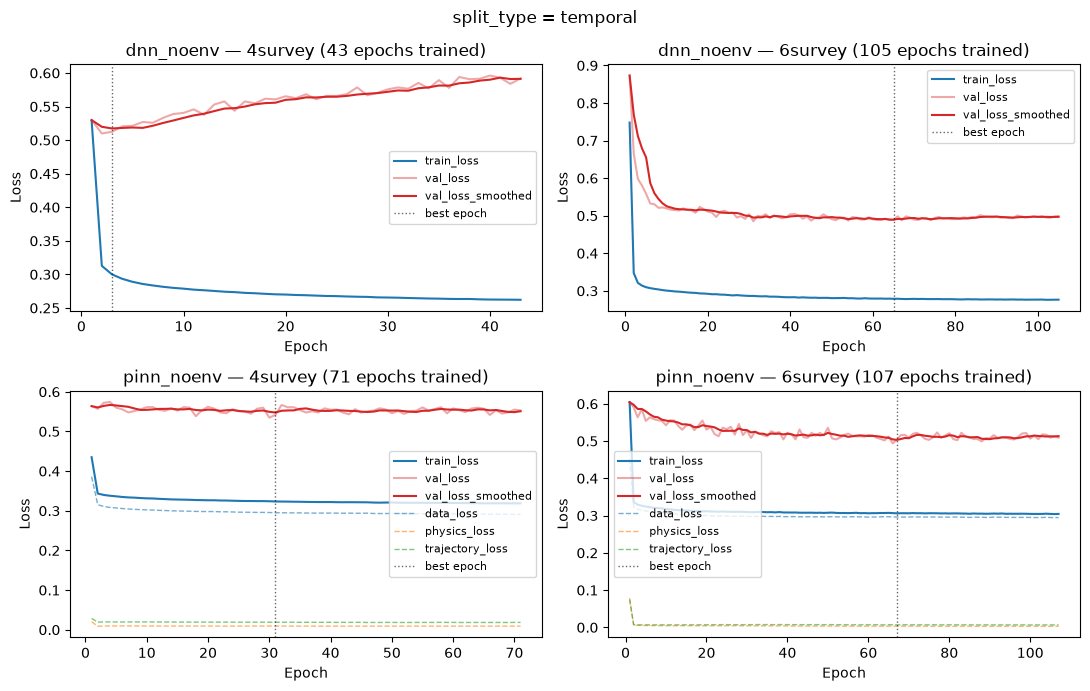

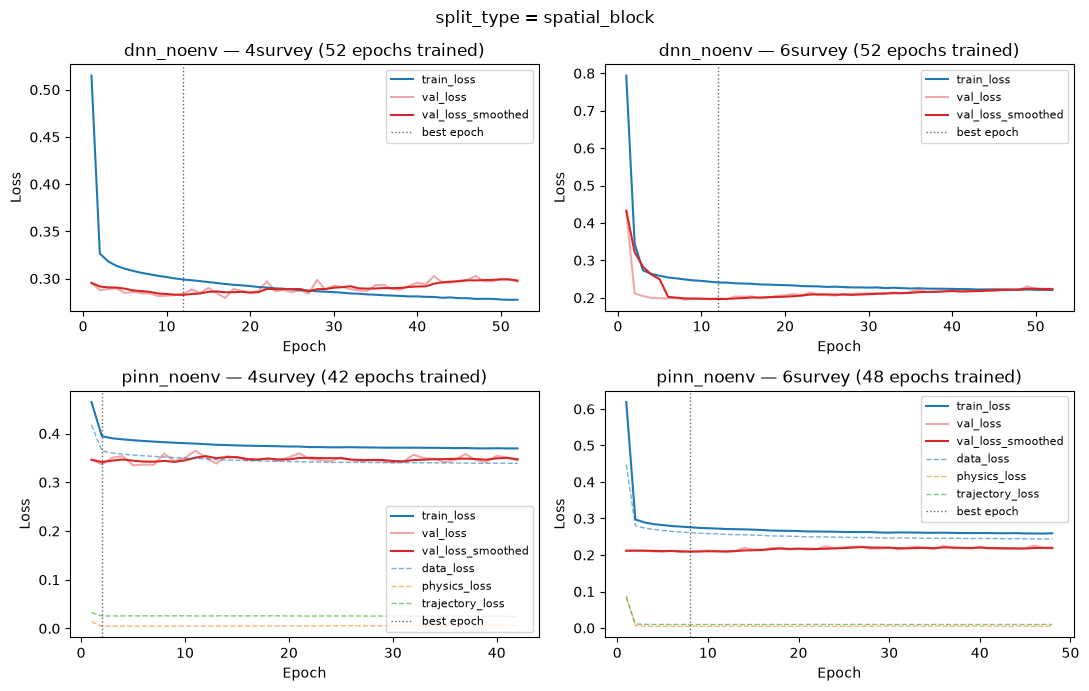

In [3]:
for split_type in SPLIT_TYPES:
    fig, axes = plt.subplots(len(NEURAL_MODELS), len(COHORTS), figsize=(11, 7))
    fig.suptitle(f"split_type = {split_type}")

    for row, model_name in enumerate(NEURAL_MODELS):
        for col, cohort in enumerate(COHORTS):
            ax = axes[row, col]
            history_path = model_output_dir(model_name, cohort, split_type=split_type) / "training_history.csv"
            if not history_path.exists():
                ax.set_title(f"{model_name} / {cohort} — not run yet")
                ax.axis("off")
                continue
            history_df = pd.read_csv(history_path)
            plot_loss_curve(history_df, ax=ax)
            ax.set_title(f"{model_name} — {cohort} ({len(history_df)} epochs trained)")

    fig.tight_layout()
    plt.show()

## 4. Test-set metrics: DNN/PINN vs. the matching-split-type baselines

Reads whatever `metrics.json` exists for each model and split type — real numbers
once the full-length runs are evaluated, sanity-check numbers before that (check
`run_metadata.json`'s `max_epochs` if unsure). Baselines are only compared within
the same split type — a `temporal` DNN result isn't a fair comparison against a
`plot_level` or `spatial_block` baseline.

In [4]:
def load_metrics(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


rows = []
for split_type in SPLIT_TYPES:
    for cohort in COHORTS:
        for model_name in BASELINE_MODELS + NEURAL_MODELS:
            metrics = load_metrics(model_output_dir(model_name, cohort, split_type=split_type) / "metrics.json")
            if metrics is not None:
                rows.append({"split_type": split_type, "cohort": cohort, "model": model_name, **metrics})

metrics_table = pd.DataFrame(rows)[["split_type", "cohort", "model", "mae", "rmse", "r2", "bias", "accuracy_pct"]]
metrics_table.sort_values(["split_type", "cohort", "rmse"])

,split_type,cohort,model,mae,rmse,r2,bias,accuracy_pct
16,spatial_block,4survey,dnn_noenv,3.780765,5.018501,0.609079,-0.000047,79.968533
17,spatial_block,4survey,pinn_noenv,4.136124,5.464151,0.536568,0.374154,77.844280
14,spatial_block,4survey,linear_baseline,4.611554,5.816721,0.474833,-0.127076,75.485714
15,spatial_block,4survey,rf_baseline,4.534183,5.988427,0.443370,0.064402,76.444318
12,spatial_block,4survey,chapman_richards,4.867781,6.107296,0.421053,1.834744,74.990029
13,spatial_block,4survey,average_by_age,5.113634,6.347579,0.374601,2.171900,74.015856
22,spatial_block,6survey,dnn_noenv,2.571547,3.649813,0.743444,-0.460653,85.563511
23,spatial_block,6survey,pinn_noenv,2.576200,3.703930,0.735780,-0.192688,85.491431
19,spatial_block,6survey,average_by_age,2.686161,3.891533,0.708337,-0.226866,84.838055
18,spatial_block,6survey,chapman_richards,2.858532,3.966825,0.696941,0.040132,84.169889


## 5. Experiments run so far (DNN/PINN specifically)

Full detail and reasoning live in `documentation/experiment_log.md`'s Findings log —
this section just points to it, not a duplicate.

- **Baselines under `temporal_split`** (2026-07-15): degraded far more than under
  `spatial_block_split` — up to +141.7% RMSE for some models. Chapman-Richards (the
  physically-constrained model) degraded least. This is the empirical case for
  building the PINN.
- **First real DNN/PINN run** (2026-07-16, `temporal_split`): both beat every
  temporal-split baseline, but the physics constraint didn't win outright — DNN won
  4survey, PINN won 6survey. The loss curves (section 3) mattered here: DNN's
  4survey `best_epoch=1` is a textbook overfitting climb, so its RMSE is closer to
  an untrained model's number than a converged one. PINN's `val_loss` on the same
  data stayed flat instead.
- **First real DNN/PINN run under `spatial_block_split`** (2026-07-16) — the split
  that matches the dissertation's central research question. Both models beat every
  spatial-block baseline on both cohorts, and beat their own `temporal_split`
  numbers too (DNN/4survey R²=0.60 here vs. 0.45 under temporal). DNN beat PINN on
  both cohorts this time, unlike the 1-1 split under temporal. Training stopped
  early (21-30 epochs, best epoch 1-10). That's not automatically a problem:
  `spatial_block`'s training set covers all four survey years per train-plot, vs.
  `temporal`'s narrow 2-year 4survey set — a richer signal a small network can fit
  fast. Whether this was real convergence or an early stop wasn't confirmed yet at
  the time — see section 6.
- **Not yet run**: hyperparameter variants (see section 6), `temporal_narrow_gap`,
  and the PINN's `cr_matched` anchor variant (see `experiment_log.md`'s naming
  glossary).

## 6. Ideas for parameter tuning

What to check in a loss curve, plus a plan for section 5's open question: is the
fast `spatial_block` convergence real, or an early stop? Cheap to test — each run
takes 15-30 minutes at these epoch counts.

### Hyperparameter-tuning plan (applies to both split types)

Checked all 8 real runs, not just `spatial_block` — **every one stopped well short
of the 500-epoch budget**:

| Split | Model | Cohort | Total epochs | Best epoch | `val_loss` start→end |
|---|---|---|---|---|---|
| temporal | dnn_noenv | 4survey | 21 | 1 | 0.51 → 0.61 (**+19%, climbs**) |
| temporal | dnn_noenv | 6survey | 54 | 34 | 0.65 → 0.49 (improves, healthy) |
| temporal | pinn_noenv | 4survey | 39 | 19 | 0.56 → 0.54 (flat, healthy) |
| temporal | pinn_noenv | 6survey | 109 | 89 | 0.65 → 0.50 (improves, healthy) |
| spatial_block | dnn_noenv | 4survey | 30 | 10 | 0.28 → 0.30 (mild drift) |
| spatial_block | dnn_noenv | 6survey | 23 | 3 | 0.21 → 0.22 (mild drift) |
| spatial_block | pinn_noenv | 4survey | 22 | 2 | 0.36 → 0.34 (flat) |
| spatial_block | pinn_noenv | 6survey | 21 | 1 | 0.21 → 0.23 (mild drift) |

**DNN is the unstable one, not PINN.** DNN is bimodal: its best case
(`temporal`/6survey) is the healthiest curve of all eight, its worst case
(`temporal`/4survey) is the worst — a textbook overfitting collapse (+19%,
monotonic, never recovers). PINN never collapses that badly; its worst drift is
still smaller than DNN's best-case improvement. **Decision: tune PINN, not DNN.**
PINN is more stable to tune from, and it's the actual research contribution of this
dissertation. DNN stays in only as the baseline comparison.

Cheapest to test first — each is a single changed constant, not a redesign, and
applies to both split types:

1. **Loosen both patience knobs.** `lr_scheduler_patience=10` and
   `early_stopping_patience=20` are too tight given how noisy `val_loss` looks
   epoch-to-epoch, and given none of the eight runs came close to the 500-epoch
   budget. Try `lr_scheduler_patience=15`, `early_stopping_patience=40`.
2. **Smooth the early-stopping criterion.** Right now, one noisy epoch can count
   toward the patience counter. Tracking a short moving average of `val_loss`
   (3-5 epochs) instead of the raw value would stop that.
3. **Increase `BATCH_SIZE`** (currently 128) for smoother, less noisy gradients.
   Combined with #2, this should show whether more training actually helps.
4. **Try SGD+Nesterov momentum instead of Adam.** This isn't adding momentum — Adam
   already uses momentum (β1=0.9). It's a genuinely different optimizer, worth an
   A/B test after #1-3.

If none of these change the result much, that's evidence the current numbers
reflect real convergence, not an early stop.

**Forward-looking note**: whatever fixes PINN's training here (no environmental
features yet) should carry over once terrain/wind features are added for the full
Env-PINN — same architecture, optimizer, and loss structure, just more features.
Worth re-checking these same questions then, not assuming they're solved.

### General loss-curve diagnostics

| What to check in the loss curve | If you see this... | ...try this |
|---|---|---|
| `val_loss` vs `train_loss` gap | `val_loss` plateaus or rises early while `train_loss` keeps falling (overfitting) — this happened to DNN/4survey under `temporal_split` | increase `L1_COEFFICIENT`, add dropout, or reduce `NoEnvNetwork`'s width/depth (`models/common/torch_model.py`) |
| `val_loss` shape | never really improves, both losses flat from the start (underfitting / stuck) | raise `LEARNING_RATE`, check `LR_SCHEDULER_PATIENCE`/`LR_SCHEDULER_FACTOR` aren't shrinking it too fast, or widen the network |
| best epoch vs. total trained | best epoch is very early and training runs long past it without improving | see the tuning plan above — could be real fast convergence or an early stop; test before assuming either |
| PINN's `physics_loss`/`trajectory_loss` vs `data_loss` | one term numerically dominates the combined `train_loss` | re-tune `PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` (`models/pinn_noenv/pinn_noenv.py`) so no single term swamps the others |
| PINN's `physics_loss`/`trajectory_loss` going to ~0 immediately | the physics terms aren't actually constraining anything (trivially satisfied) | check they're computed against the *unscaled* CR curve correctly, and that `frozen_cr_params` in `run_metadata.json` are sensible, not degenerate |
| DNN vs PINN, same split type | PINN's test RMSE isn't better than the DNN's | not automatically a bug — check the loss curves, not just final RMSE. DNN's wins so far have coincided with its overfitting cases |
| Same model, `temporal` vs. `spatial_block` | very different loss-curve shape/stability between the two splits | expected to some degree — `spatial_block`'s training set covers all four survey years per train-plot; `temporal`'s 4survey set has only two years |

Also planned (see `experiment_log.md`'s "Planned robustness checks" table, not yet
triggered): `temporal_narrow_gap`, and the PINN's `cr_matched` anchor variant.

## 7. Tuning result, both split types: before vs after

Compares the pre-tuning runs (`git_commit=ba54e94`/`3fb0d3f`/`7f157eb`) to the tuned
runs (`git_commit=00ac596` or later). What changed: `LR_SCHEDULER_PATIENCE` 10→15,
`BATCH_SIZE` 128/32→512/128, `EARLY_STOPPING_PATIENCE` 20→40, added `WEIGHT_DECAY` and
`GRAD_CLIP_MAX_NORM`, and best epoch is now picked from a 5-epoch moving average of
`val_loss` instead of the raw per-epoch value.

Note: `best_epoch_after` uses that moving average, `best_epoch_before` uses the raw
value — different methods, not a mistake.

In [5]:
# Pre-tuning numbers, typed in by hand from section 6's table. The old
# training_history.csv files got overwritten when the tuned runs saved to
# the same path, so this is all that's left of them.
BEFORE_TUNING = {
    ("temporal", "dnn_noenv", "4survey"): {"n_epochs": 21, "best_epoch": 1, "val_loss_start": 0.51, "val_loss_end": 0.61},
    ("temporal", "dnn_noenv", "6survey"): {"n_epochs": 54, "best_epoch": 34, "val_loss_start": 0.65, "val_loss_end": 0.49},
    ("temporal", "pinn_noenv", "4survey"): {"n_epochs": 39, "best_epoch": 19, "val_loss_start": 0.56, "val_loss_end": 0.54},
    ("temporal", "pinn_noenv", "6survey"): {"n_epochs": 109, "best_epoch": 89, "val_loss_start": 0.65, "val_loss_end": 0.50},
    ("spatial_block", "dnn_noenv", "4survey"): {"n_epochs": 30, "best_epoch": 10, "val_loss_start": 0.28, "val_loss_end": 0.30},
    ("spatial_block", "dnn_noenv", "6survey"): {"n_epochs": 23, "best_epoch": 3, "val_loss_start": 0.21, "val_loss_end": 0.22},
    ("spatial_block", "pinn_noenv", "4survey"): {"n_epochs": 22, "best_epoch": 2, "val_loss_start": 0.36, "val_loss_end": 0.34},
    ("spatial_block", "pinn_noenv", "6survey"): {"n_epochs": 21, "best_epoch": 1, "val_loss_start": 0.21, "val_loss_end": 0.23},
}

rows = []
for split_type in SPLIT_TYPES:
    for model_name in NEURAL_MODELS:
        for cohort in COHORTS:
            before = BEFORE_TUNING[(split_type, model_name, cohort)]
            history_path = model_output_dir(model_name, cohort, split_type=split_type) / "training_history.csv"
            if not history_path.exists():
                continue
            history_df = pd.read_csv(history_path)
            best_idx = history_df["val_loss_smoothed"].idxmin()
            rows.append({
                "split_type": split_type,
                "model": model_name,
                "cohort": cohort,
                "n_epochs_before": before["n_epochs"],
                "n_epochs_after": len(history_df),
                "best_epoch_before": before["best_epoch"],
                "best_epoch_after": int(history_df.loc[best_idx, "epoch"]),
                "val_loss_start_before": before["val_loss_start"],
                "val_loss_start_after": round(float(history_df["val_loss"].iloc[0]), 4),
                "val_loss_end_before": before["val_loss_end"],
                "val_loss_end_after": round(float(history_df["val_loss"].iloc[-1]), 4),
                "val_loss_best_smoothed_after": round(float(history_df["val_loss_smoothed"].min()), 4),
            })

tuning_comparison = pd.DataFrame(rows)
tuning_comparison

,split_type,model,cohort,n_epochs_before,n_epochs_after,best_epoch_before,best_epoch_after,val_loss_start_before,val_loss_start_after,val_loss_end_before,val_loss_end_after,val_loss_best_smoothed_after
0,temporal,dnn_noenv,4survey,21,43,1,3,0.51,0.5298,0.61,0.5919,0.5173
1,temporal,dnn_noenv,6survey,54,105,34,65,0.65,0.8731,0.49,0.4986,0.4895
2,temporal,pinn_noenv,4survey,39,71,19,31,0.56,0.5638,0.54,0.5531,0.5477
3,temporal,pinn_noenv,6survey,109,107,89,67,0.65,0.6041,0.50,0.5093,0.5032
4,spatial_block,dnn_noenv,4survey,30,52,10,12,0.28,0.2955,0.30,0.2966,0.2828
5,spatial_block,dnn_noenv,6survey,23,52,3,12,0.21,0.4325,0.22,0.2216,0.1967
6,spatial_block,pinn_noenv,4survey,22,42,2,2,0.36,0.3463,0.34,0.3448,0.3415
7,spatial_block,pinn_noenv,6survey,21,48,1,8,0.21,0.2117,0.23,0.2175,0.2095
